# RhetFig Analysis

## Import Packages

In [1]:
import pandas as pd
import re
from functools import reduce
from spacy.tokenizer import Tokenizer
from spacy.lang.en import English
import nltk
from nltk.corpus import stopwords 
nlp = English()
tokenizer = Tokenizer(nlp.vocab)
import matplotlib.pyplot as plt

## Reading and Cleaning Data

### Metaphor Annotations

In [2]:
# load in CMT annotation json and save it to a pandas dataframe
file_path = 'RhetFig_May19_2026.json'
rhet_df = pd.read_json(file_path)

In [3]:
# extracting labels from the annotations column
rhet_df['labels'] = rhet_df.apply(lambda row: row.annotations[0]['result'], axis=1)

# cleaning up file names 
rhet_df['filename'] = rhet_df.apply(lambda row: re.sub(r"^[^_]*-", '', row.file_upload), axis=1)
rhet_df['filename'] = rhet_df.apply(lambda row: re.sub(r"_fixed", '', row.filename[:-4].lower()), axis=1)
rhet_df['filename'] = rhet_df.apply(lambda row: re.sub(r"aboriginal", 'indigenous', row.filename), axis=1)

In [4]:
# creating a dictionary of metaphor labels, where each key is a filename
sarcasm_cnt = 0
rhet_labels = {}
for name in rhet_df['filename'].unique():
    # creating a new dataframe only containing labels corresponding to one file
    new_df = rhet_df[rhet_df['filename']==name][['filename', 'labels']].reset_index()
    # creating a list to save the labels in 
    labels_dic = {}
    for el in new_df['labels'][0]:
        # adding labels to the label list 
        try:
            el['from_name']=='source'
            start = el['value']['start']
            end = el['value']['end']
            for fig in el['value']['taxonomy']:
                if len(fig) > 1: # e.g., ['Irony'. 'Sarcasm'] <- length will always be 1 unless there's a taxonomy
                    if 'Sarcasm' in fig:
                        sarcasm_cnt +=1 
                    label_figure = fig[0] #fig[0] will be Irony, fig[1] will be the subtype
                else: 
                    label_figure = fig[0].replace('Verbal Irony', 'Irony').replace('Synedoche', 'Synecdoche') #replacing typo & holdovers from round 1
                try: 
                    if [start, end] not in labels_dic[label_figure]:
                        labels_dic[label_figure].append([start,end])
                except KeyError: 
                    labels_dic[label_figure] = [[start,end]]
                    # if 'Irony' in label_figure or 'Sarcasm' in label_figure:
                    #     print(labels_dic)
        except KeyError:
            print(el) #these errors correspond to directional labels
    # saving the dic of labels to the dictionary of filenames
    rhet_labels[name] = labels_dic
print(sarcasm_cnt)

{'from_id': 'k1wDguFaUx', 'to_id': 'D6l9c9j9Ec', 'type': 'relation', 'direction': 'right'}
{'from_id': 'llpBo9pgq4', 'to_id': 'L4OqMa4rDB', 'type': 'relation', 'direction': 'right'}
{'from_id': 'nqe6fV-DqG', 'to_id': '8R39NyrMgZ', 'type': 'relation', 'direction': 'right'}
{'from_id': 'N6cnbVpzKN', 'to_id': 'IaDeXnHv-0', 'type': 'relation', 'direction': 'right'}
{'from_id': 'VcV-HgZ-qb', 'to_id': 'CvQ46bQ-pS', 'type': 'relation', 'direction': 'right'}
{'from_id': 'w77jM85eaK', 'to_id': 'ywLTszm2ZE', 'type': 'relation', 'direction': 'right'}
88


## Corpus Analysis

In [5]:
# creating a new dataframe based on the metaphor dataframe, with fewer columns
df_analysis=rhet_df[['filename', 'data']]
# creating a column that measures the length of the text associated with each filename
df_analysis['length'] = df_analysis.apply(lambda row: len(tokenizer(row.data['text'])), axis=1)

C:\Users\romha\AppData\Local\Temp\ipykernel_24172\3176803537.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_analysis['length'] = df_analysis.apply(lambda row: len(tokenizer(row.data['text'])), axis=1)


In [6]:
# shortest comments
df_analysis.loc[(df_analysis.length == min(df_analysis.length))]

,filename,data,length
191,belgium_127,{'text': '!!!!!!!!!!!!!!'},1
343,china_39,{'text': 'LOL...!'},1
762,trump_38,{'text': 'Ha-Ha-Ha!!!'},1
983,watch_30,{'text': 'Baloney.'},1
990,watch_37,{'text': 'Exactly!'},1


In [7]:
# longest
df_analysis.loc[(df_analysis.length == max(df_analysis.length))]

,filename,data,length
943,uber_94,{'text': 'Uber drivers have filed a class acti...,793


In [8]:
# statistics
print('There are {} comments in the corpus. The comments range between {} and {} in number of tokens, with an average of {}. \
The total number of tokens in the corpus is {}.'.format(len(df_analysis), min(df_analysis.length), 
                                                        max(df_analysis.length), sum(df_analysis.length)/len(df_analysis), 
                                                        sum(df_analysis.length)))

There are 1043 comments in the corpus. The comments range between 1 and 793 in number of tokens, with an average of 62.215723873441995. The total number of tokens in the corpus is 64891.


In [9]:
# count unique labels
unique_cnt = 0
for key in rhet_labels.keys():
    lst = []
    for val in rhet_labels[key].values():
        for el in val:
            if el not in lst:
                lst.append(el)
    unique_cnt += len(lst)

In [14]:
# creating a list to contain the length of each label
# (the spans are not unique; so number of labels =/= number of metaphors) 
labels_diff = []
for all_labels in rhet_labels.values():
    for label in all_labels.values():
        for indices in label:
            # calculating the difference in indices
            length=indices[1]-indices[0]
            # appending the length to the list
            labels_diff.append(length)
print('There are {} labels in the RhetFig annotation layer, corresponding to {} unique units, \
and the average span of each label is {} characters.'.format(len(labels_diff), unique_cnt, 
                                                             sum(labels_diff)/len(labels_diff)))

There are 2126 labels in the RhetFig annotation layer, corresponding to 1978 unique units, and the average span of each label is 46.55315145813735 characters.


### Measuring figure density by identifying labelled text, tokenizing, summing and dividing over total number of tokens:

In [15]:
def labelled_char(annotations):
    '''
    ListOfDict -> ListOfInt
    takes in a list of dictionaries with start and end values and returns list of characters contained in a label
    '''
    # setting list of labelled characters
    lst = []
    try:
        for el in annotations[0]['result']:
            # adds characters from label to the list
            lst = lst + list(range(el['value']['start'], el['value']['end']))
    except KeyError:
        print('no results!')
    # set gets rid of duplicates
    return list(set(lst))

In [16]:
def num_labelled_tokens(data, chars):
    '''
    ListOfInt -> Int
    takes in a list of the characters contained in a label and returns the number of labelled tokens
    '''
    labelled = ''
    for ind in range(len(chars)):
        ch = chars[ind]
    
        try:
            if chars[ind] + 1 == chars[ind+1]:
                labelled = labelled + data['text'][ch]
            else:
                labelled = labelled + data['text'][ch] + ' '
        except IndexError:
            return len(tokenizer(labelled))

In [17]:
# a new column containing the labelled characters in each comment
rhet_df['characters_labelled']=rhet_df.apply(lambda row: labelled_char(row.annotations), axis=1)

no results!
no results!
no results!
no results!
no results!
no results!


In [18]:
# dividing the total number of labelled tokens over the total number of tokens
int(rhet_df.apply(lambda row: num_labelled_tokens(row.data, row.characters_labelled), axis=1).sum())/sum(df_analysis.length)

0.2519147493489082

## Results

### Ranking Rhetorical Figures

In [19]:
# creating a list of all the potential sources
rhetfig_list = []
for file in rhet_labels.keys():
    rhetfig_list.extend(list(rhet_labels[file]))

In [20]:
def rhetfig_counts(labels_dic):
    '''
    takes a dictionary of labels as input and returns a dataframe that has a label column, a count column, and a frequency column
    '''
    # creating a dictionary where every potential rhetfig is a key and setting the values to zero
    rhetfig_dic = {}
    for rhetfig in set(rhetfig_list):
        rhetfig_dic[rhetfig]=0
    # populating the dictionary by counting the number of occurences for each rhetfig
    for file in labels_dic.keys():
        # going through each rhetfig in the file's labels 
        for rhetfig in labels_dic[file].keys():
            # updating the count in the rhetfig dictionary
            rhetfig_dic[rhetfig] = rhetfig_dic[rhetfig] + len(labels_dic[file][rhetfig])
    rhetfig_count_df = pd.DataFrame(rhetfig_dic.items(), columns=['label','count'])
    total = rhetfig_count_df['count'].sum()
    rhetfig_count_df['frequency'] = rhetfig_count_df.apply(lambda row: int(row['count'])/total, axis=1)
    return rhetfig_count_df.sort_values(by='count', ascending=False)
#return sorted(rhetfig_dic.items(), key=lambda x: x[1], reverse=True)

In [21]:
# top rhetfig overall
top_rhetfig = rhetfig_counts(rhet_labels)
top_rhetfig

,label,count,frequency
0,Metonymy,522,0.245532
7,Personification,383,0.180151
11,Hyperbole,349,0.164158
6,Rhetorical Question,331,0.155691
3,Irony,150,0.070555
8,Antithesis,128,0.060207
2,Allusion,102,0.047977
1,Euphemism,49,0.023048
9,Simile,41,0.019285
10,Puns/Wordplay,38,0.017874


In [22]:
#top_rhetfig.to_csv('label_counts.csv')

In [23]:
# list of topics
p = re.compile(r'\D*(?=_\d+)')
filename_topics = [p.match(name).group(0) for name in rhet_df.filename.values]
unique_topics = []
for topic in filename_topics:
    if topic not in unique_topics:
        unique_topics.append(topic) 

In [24]:
# counting labels by topic and creating a df
labels_by_topic = {}
count_df_by_topic = {}
for topic in unique_topics:
    labels_by_topic[topic]= dict(filter(lambda item: topic in item[0], rhet_labels.items()))
    count_df_by_topic[topic] = rhetfig_counts(labels_by_topic[topic])

# rename columns by topic
for topic in count_df_by_topic.keys():
    count_df_by_topic[topic]=count_df_by_topic[topic].rename(columns={'count':f'{topic}_count','frequency':f'{topic}_frequency'})

# a list of the dataframes created for each topic
dataframes = [top_rhetfig]
for topic in count_df_by_topic.keys():
    dataframes.append(count_df_by_topic[topic])

# joining all dataframes 
labels_over_all_topics = reduce(lambda  left,right: pd.merge(left,right,on=['label'], how='outer'), dataframes)

# plots

In [25]:
labels_sorted = labels_over_all_topics.sort_values(by='count', ascending=False)#.plot()

In [26]:
p = re.compile(r'\D*_frequency')
freq_columns = [col for col in labels_sorted.columns if p.match(col)]

<Axes: xlabel='label'>

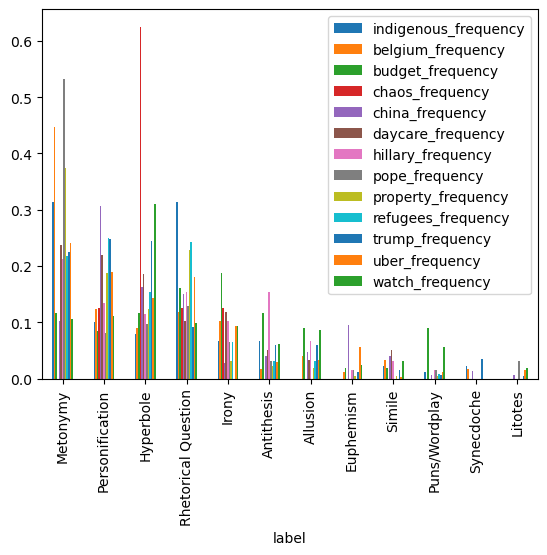

In [27]:
labels_sorted.plot(x='label',y=freq_columns,kind='bar')

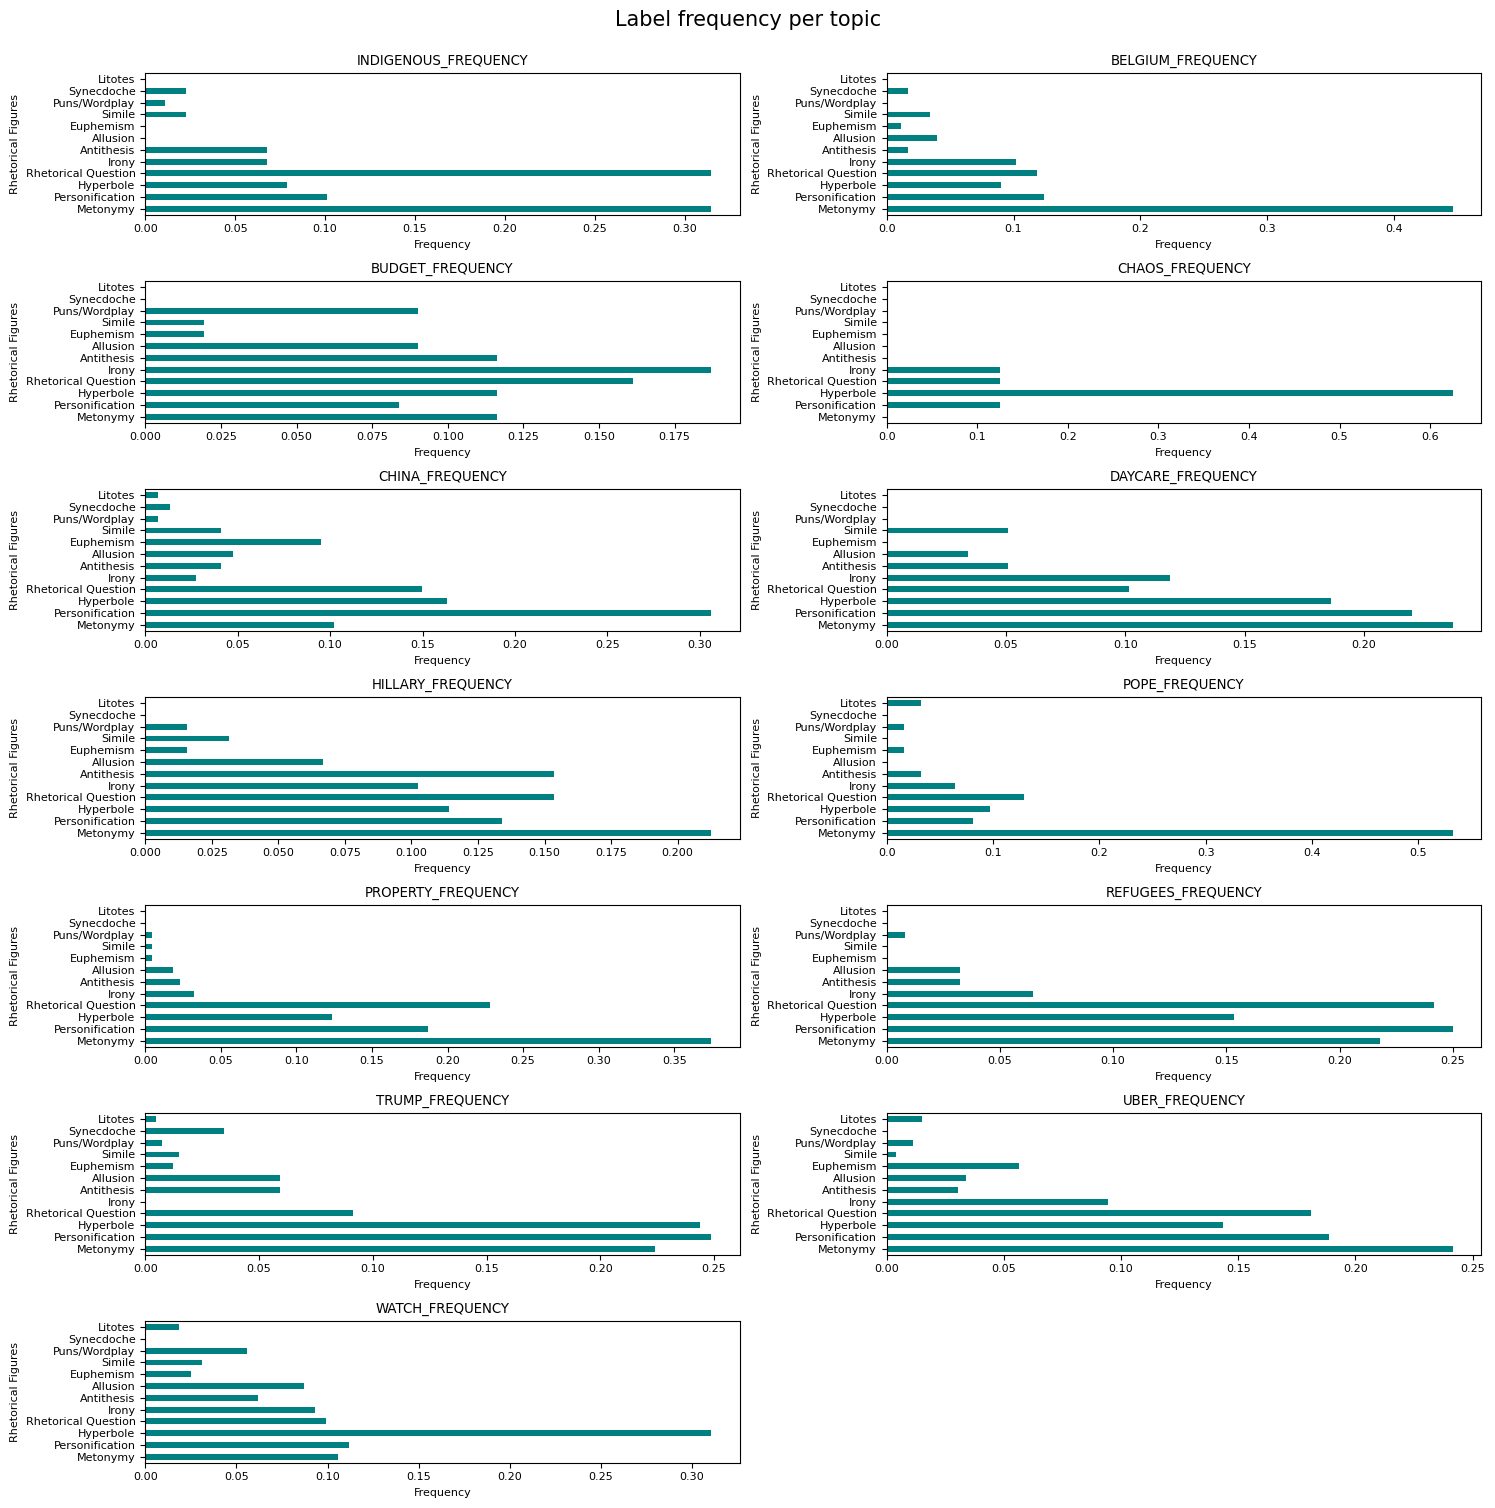

In [28]:
# plotting frequency in each topic
plt.figure(figsize=(15, 15))
plt.rcParams.update({'font.size':8})
#plt.subplots_adjust(hspace=1.5)
plt.suptitle("Label frequency per topic", fontsize=15, y=1)

# loop through the length of tickers and keep track of index
for n, topic in enumerate(freq_columns):
    # add a new subplot iteratively
    ax = plt.subplot(7, 2, n + 1)

    # filter df and plot ticker on the new subplot axis
    labels_sorted.plot(x='label',y=topic,ax=ax, kind ='barh', color='teal')

    # chart formatting
    ax.set_title(topic.upper())
    ax.get_legend().remove()
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Rhetorical Figures")
plt.tight_layout()
plt.savefig('rhetfig_per_topic.png')